# Titanic Survival Prediction – Machine Learning Project

This notebook builds a machine learning model to predict whether a passenger survived the Titanic disaster.
The workflow includes:
1. Data loading
2. Exploratory Data Analysis
3. Data preprocessing
4. Feature engineering
5. Model training
6. Model evaluation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier

## Load Dataset

In [2]:
df = pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Basic Dataset Information

In [3]:
print("Shape of dataset:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())

Shape of dataset: (891, 12)

Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Missing values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


## Exploratory Data Analysis

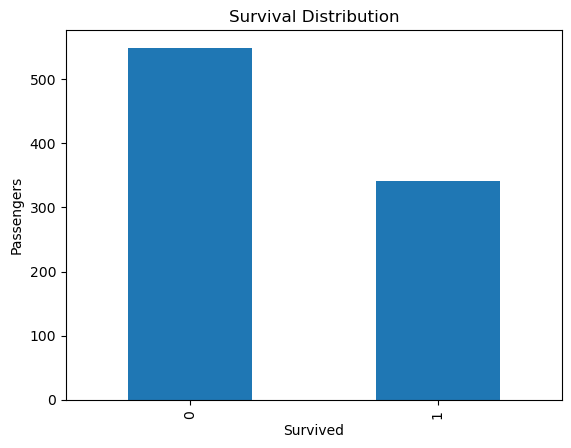

In [4]:
plt.figure()
df['Survived'].value_counts().plot(kind='bar')
plt.title("Survival Distribution")
plt.xlabel("Survived")
plt.ylabel("Passengers")
plt.show()

<Figure size 640x480 with 0 Axes>

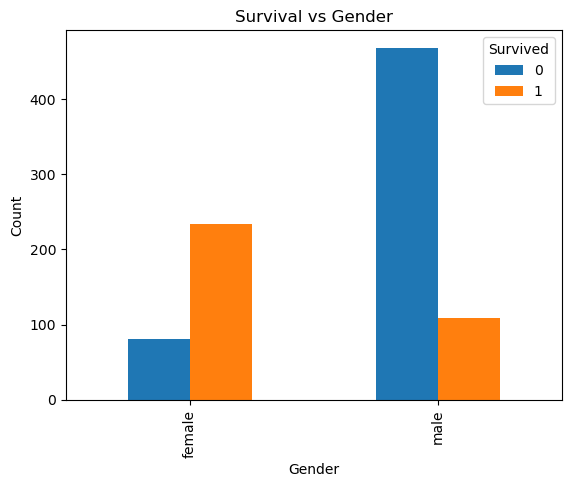

In [5]:
plt.figure()
pd.crosstab(df['Sex'], df['Survived']).plot(kind='bar')
plt.title("Survival vs Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

<Figure size 640x480 with 0 Axes>

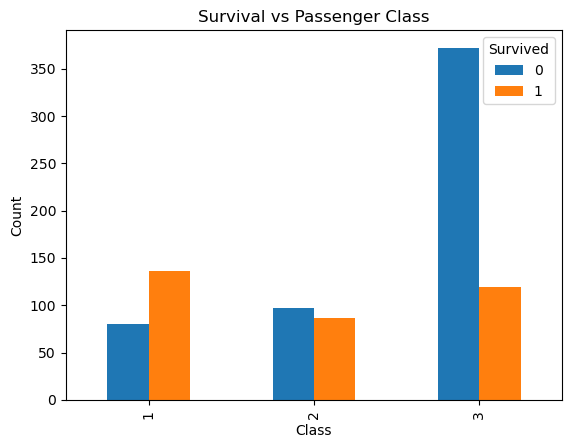

In [6]:
plt.figure()
pd.crosstab(df['Pclass'], df['Survived']).plot(kind='bar')
plt.title("Survival vs Passenger Class")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

## Data Cleaning

In [7]:
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Drop less useful columns
df.drop(['Cabin','Ticket','Name'], axis=1, inplace=True)

C:\Users\de\AppData\Local\Temp\ipykernel_28088\3298697790.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
C:\Users\de\AppData\Local\Temp\ipykernel_28088\3298697790.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example

In [8]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64

## Encoding Categorical Features

In [10]:
le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

## Feature Selection

In [11]:
X = df.drop(['Survived','PassengerId'], axis=1)
y = df['Survived']

## Train-Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

## Train Random Forest Model

In [13]:
model = RandomForestClassifier(n_estimators=150, random_state=1)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=150, random_state=1)

## Model Prediction

In [14]:
predictions = model.predict(X_test)

## Model Evaluation

In [18]:
print("Accuracy:", accuracy_score(y_test, predictions))
print(classification_report(y_test, predictions))

Accuracy: 0.7932960893854749
              precision    recall  f1-score   support

           0       0.79      0.90      0.84       106
           1       0.81      0.64      0.72        73

    accuracy                           0.79       179
   macro avg       0.80      0.77      0.78       179
weighted avg       0.80      0.79      0.79       179



## Feature Importance

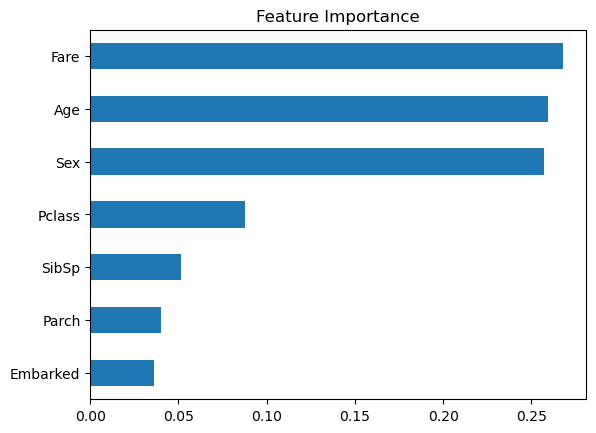

In [16]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

## Conclusion

The model predicts Titanic survival using passenger information such as:
- Passenger class
- Gender
- Age
- Family size
- Ticket fare

Random Forest performs well for this classification task and provides insight into which features influence survival the most.
